<a href="https://colab.research.google.com/github/ugoincc/pml-video-game-sales/blob/main/eda_dataset_raw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎮 Análise Exploratória de Dados — Video Games Sales (1980–2024)
### Etapa 2b — Análise do Dataset Raw

> **Objetivo:** Compreender a estrutura, características e distribuição do dataset original sem aplicar filtros ou tomar decisões de modelagem.  
> **Dataset:** `Video_Games_Sales_19802024__Raw.csv` — 64.016 registros, 14 colunas originais.

---


## 1. Instalações e Importações

In [ ]:
# Instalar bibliotecas extras se necessário
# !pip install pandas matplotlib seaborn numpy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Estilo global ────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.family'       : 'DejaVu Sans',
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 10,
    'axes.grid'         : True,
    'grid.alpha'        : 0.25,
    'grid.linestyle'    : '--',
})

BLUE   = '#3a6fa8'
ORANGE = '#d9693a'
GREEN  = '#4e9e6e'
RED    = '#c0392b'
PURPLE = '#8e44ad'
GRAY   = '#888888'

print("✅ Bibliotecas carregadas com sucesso!")


✅ Bibliotecas carregadas com sucesso!


## 2. Carregamento e Inspeção Inicial

Carregamos o dataset **raw** sem nenhum pré-processamento.  
Derivamos duas colunas auxiliares de `release_date` apenas para análise temporal.


In [ ]:
# ── Carregar dataset ─────────────────────────────────────────────────
# Se estiver no Colab, faça upload do arquivo ou monte o Google Drive:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('Video_Games_Sales_19802024__Raw.csv')

# Colunas auxiliares de data (apenas para análise — sem modificar o raw)
df['release_year']  = pd.to_datetime(df['release_date'], errors='coerce', dayfirst=True).dt.year
df['release_month'] = pd.to_datetime(df['release_date'], errors='coerce', dayfirst=True).dt.month

print(f"Shape: {df.shape}")
print(f"\nColunas originais: {df.columns.tolist()}")
df.head(5)

Shape: (64016, 16)

Colunas originais: ['img', 'title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_date', 'last_update', 'release_year', 'release_month']


,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update,release_year,release_month
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN,2013.0,9.0
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18-11-2014,03-01-2018,2014.0,11.0
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28-10-2002,NaN,2002.0,10.0
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,17-09-2013,NaN,2013.0,9.0
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06-11-2015,14-01-2018,2015.0,11.0


In [ ]:
# ── Tipos e nulos ────────────────────────────────────────────────────
print("=== Tipos de dados ===")
print(df.dtypes)
print("\n=== Valores nulos ===")
nulos = pd.DataFrame({
    'Coluna'     : df.columns,
    'Nulos (N)'  : df.isnull().sum().values,
    '% Ausente'  : (df.isnull().mean() * 100).round(1).values,
    '% Presente' : ((1 - df.isnull().mean()) * 100).round(1).values,
})
print(nulos.to_string(index=False))


=== Tipos de dados ===
img               object
title             object
console           object
genre             object
publisher         object
developer         object
critic_score     float64
total_sales      float64
na_sales         float64
jp_sales         float64
pal_sales        float64
other_sales      float64
release_date      object
last_update       object
release_year     float64
release_month    float64
dtype: object

=== Valores nulos ===
       Coluna  Nulos (N)  % Ausente  % Presente
          img          0        0.0       100.0
        title          0        0.0       100.0
      console          0        0.0       100.0
        genre          0        0.0       100.0
    publisher          0        0.0       100.0
    developer         17        0.0       100.0
 critic_score      57338       89.6        10.4
  total_sales      45094       70.4        29.6
     na_sales      51379       80.3        19.7
     jp_sales      57290       89.5        10.5
    pal_sale

## 3. Estrutura e Completude do Dataset

Visualizamos a completude de cada coluna e como o volume se reduz conforme aplicamos
os critérios de disponibilidade das colunas mais importantes.


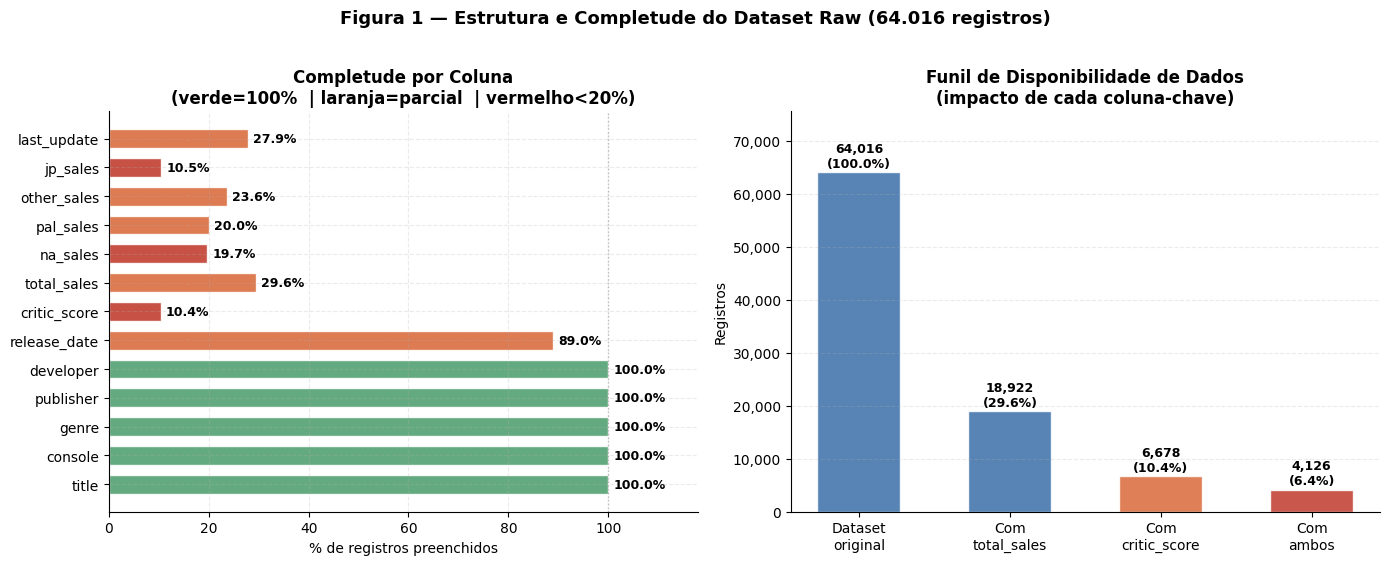

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Figura 1 — Estrutura e Completude do Dataset Raw (64.016 registros)',
             fontsize=13, fontweight='bold', y=1.02)

# ── 3a: Completude por coluna ────────────────────────────────────────
ax = axes[0]
cols_vis = ['title','console','genre','publisher','developer',
            'release_date','critic_score','total_sales',
            'na_sales','pal_sales','other_sales','jp_sales','last_update']
pcts = [(1 - df[c].isnull().mean()) * 100 for c in cols_vis]
bar_colors = [GREEN if p >= 99 else ORANGE if p >= 20 else RED for p in pcts]

bars = ax.barh(cols_vis, pcts, color=bar_colors, alpha=0.88, edgecolor='white', height=0.65)
ax.set_xlim(0, 118)
ax.axvline(100, color=GRAY, lw=1, ls=':', alpha=0.5)
ax.set_xlabel('% de registros preenchidos')
ax.set_title('Completude por Coluna\n(verde=100%  | laranja=parcial  | vermelho<20%)')
for bar, val in zip(bars, pcts):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# ── 3b: Funil de disponibilidade ─────────────────────────────────────
ax = axes[1]
stages  = ['Dataset\noriginal', 'Com\ntotal_sales', 'Com\ncritic_score', 'Com\nambos']
values  = [len(df),
           df['total_sales'].notna().sum(),
           df['critic_score'].notna().sum(),
           df.dropna(subset=['total_sales','critic_score']).shape[0]]
pcts_f  = [v / len(df) * 100 for v in values]
colors_f = [BLUE, BLUE, ORANGE, RED]

bars2 = ax.bar(stages, values, color=colors_f, alpha=0.85, width=0.55, edgecolor='white')
ax.set_title('Funil de Disponibilidade de Dados\n(impacto de cada coluna-chave)')
ax.set_ylabel('Registros')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val, pct in zip(bars2, values, pcts_f):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=9, fontweight='bold')
ax.set_ylim(0, max(values) * 1.18)
ax.grid(axis='y', alpha=0.25)
ax.grid(axis='x', visible=False)

plt.tight_layout()
plt.savefig('fig1_estrutura_completude.png', dpi=150, bbox_inches='tight')
plt.show()


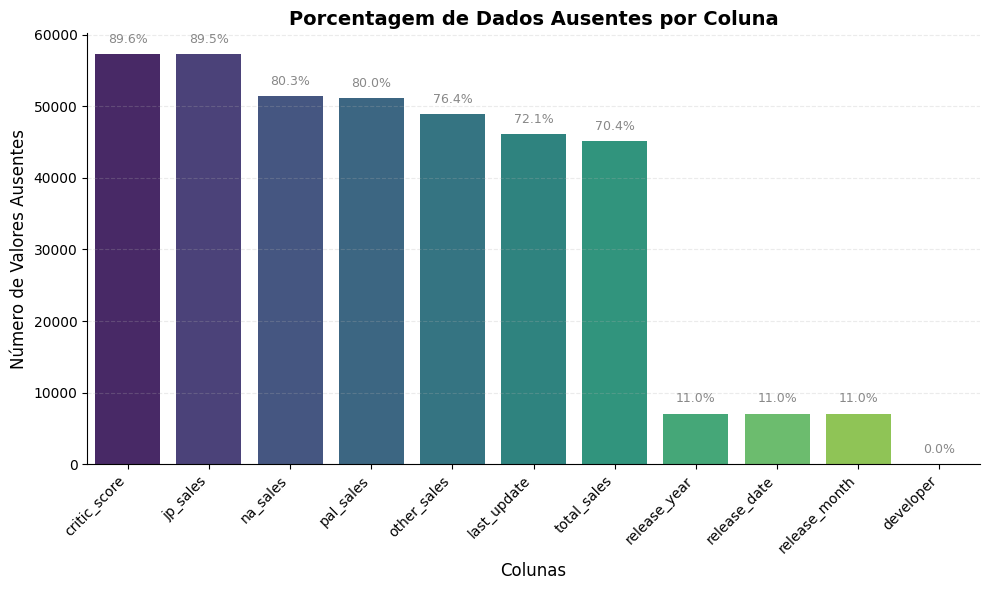

In [ ]:
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if not missing_data.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=missing_data.index, y=missing_data.values, palette='viridis', ax=ax)
    ax.set_title('Porcentagem de Dados Ausentes por Coluna', fontsize=14, fontweight='bold')
    ax.set_xlabel('Colunas', fontsize=12)
    ax.set_ylabel('Número de Valores Ausentes', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    for i, (col, count) in enumerate(missing_data.items()):
        pct = (count / len(df)) * 100
        ax.text(i, count + (max(missing_data.values) * 0.02), f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, color=GRAY)
    plt.tight_layout()
    plt.savefig('missing_data_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Não há dados ausentes no dataset.')

## 4. Distribuição de Vendas (`total_sales`)

`total_sales` é a variável mais importante do dataset — qualquer definição de "sucesso" ou
classe alvo virá dela. Analisamos sua distribuição completa **sem aplicar nenhum threshold**.


In [ ]:
ts = df['total_sales'].dropna()

print("=== Estatísticas de total_sales ===")
stats = ts.describe()
print(stats.round(3))
print(f"\nAssimetria (skew): {ts.skew():.3f}")
print(f"Curtose:            {ts.kurt():.3f}")
print(f"\nPercentis:")
for p in [50, 75, 80, 90, 95, 99]:
    print(f"  {p:>3}%: {ts.quantile(p/100):.3f}M")


=== Estatísticas de total_sales ===
count    18922.000
mean         0.349
std          0.807
min          0.000
25%          0.030
50%          0.120
75%          0.340
max         20.320
Name: total_sales, dtype: float64

Assimetria (skew): 8.775
Curtose:            125.552

Percentis:
   50%: 0.120M
   75%: 0.340M
   80%: 0.450M
   90%: 0.830M
   95%: 1.370M
   99%: 3.540M


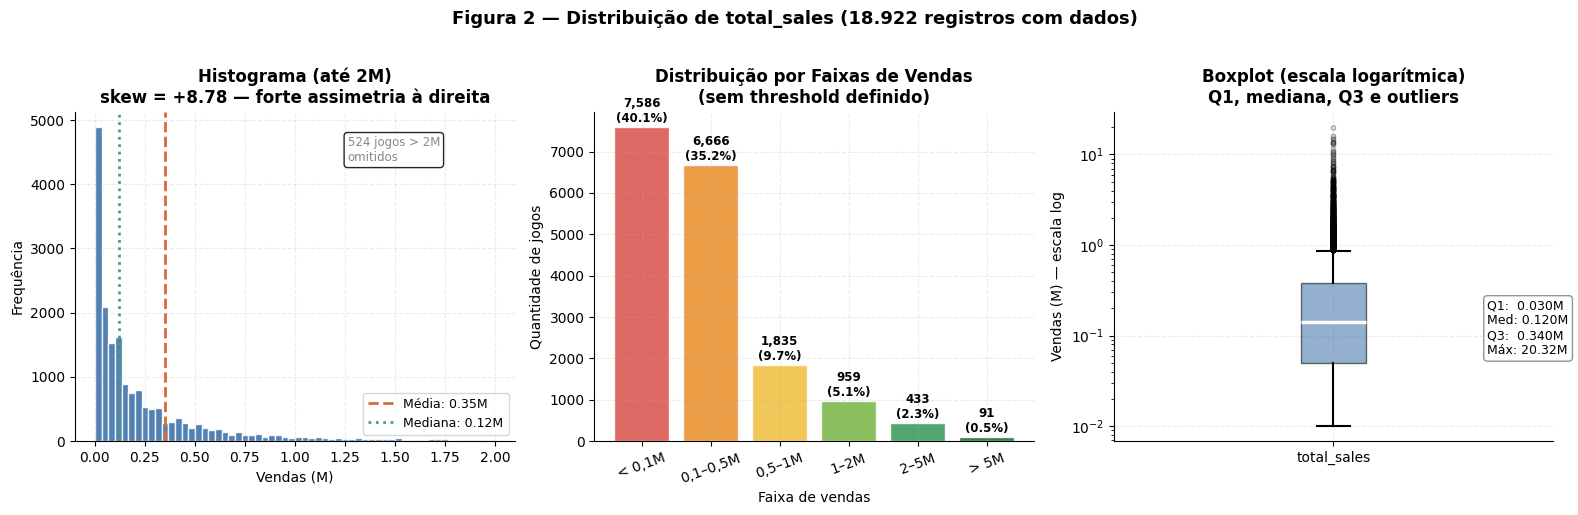

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figura 2 — Distribuição de total_sales (18.922 registros com dados)',
             fontsize=13, fontweight='bold', y=1.02)

# ── 4a: Histograma (até 2M) ──────────────────────────────────────────
ax = axes[0]
ax.hist(ts[ts <= 2], bins=60, color=BLUE, edgecolor='white', alpha=0.88)
ax.axvline(ts.mean(),   color=ORANGE, lw=2, ls='--', label=f'Média: {ts.mean():.2f}M')
ax.axvline(ts.median(), color=GREEN,  lw=2, ls=':',  label=f'Mediana: {ts.median():.2f}M')
ax.set_title(f'Histograma (até 2M)\nskew = +{ts.skew():.2f} — forte assimetria à direita')
ax.set_xlabel('Vendas (M)')
ax.set_ylabel('Frequência')
ax.legend(fontsize=9)
n_above = (ts > 2).sum()
ax.text(0.62, 0.85, f'{n_above} jogos > 2M\nomitidos', transform=ax.transAxes,
        fontsize=8.5, color=GRAY,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

# ── 4b: Faixas naturais de vendas ────────────────────────────────────
ax = axes[1]
bins_v   = [0, 0.1, 0.5, 1.0, 2.0, 5.0, np.inf]
labels_v = ['< 0,1M', '0,1–0,5M', '0,5–1M', '1–2M', '2–5M', '> 5M']
counts_v = pd.cut(ts, bins=bins_v, labels=labels_v).value_counts().reindex(labels_v)
palette_v = ['#d9534f','#e8902a','#f0c040','#7ab648','#3a9a5c','#1a6e3c']

bars = ax.bar(labels_v, counts_v.values, color=palette_v, edgecolor='white', alpha=0.88)
ax.set_title('Distribuição por Faixas de Vendas\n(sem threshold definido)')
ax.set_ylabel('Quantidade de jogos')
ax.set_xlabel('Faixa de vendas')
ax.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, counts_v.values):
    pct = val / len(ts) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# ── 4c: Boxplot escala log ───────────────────────────────────────────
ax = axes[2]
ts_pos = ts[ts > 0]
bp = ax.boxplot(ts_pos, vert=True, patch_artist=True,
                boxprops=dict(facecolor=BLUE, alpha=0.55),
                medianprops=dict(color='white', linewidth=2.5),
                flierprops=dict(marker='o', ms=3, alpha=0.2, color=GRAY),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5))
ax.set_yscale('log')
ax.set_title('Boxplot (escala logarítmica)\nQ1, mediana, Q3 e outliers')
ax.set_ylabel('Vendas (M) — escala log')
ax.set_xticklabels(['total_sales'])
stats_txt = (f"Q1:  {ts.quantile(0.25):.3f}M\n"
             f"Med: {ts.median():.3f}M\n"
             f"Q3:  {ts.quantile(0.75):.3f}M\n"
             f"Máx: {ts.max():.2f}M")
ax.text(1.35, ts.median(), stats_txt, va='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor=GRAY, alpha=0.9))

plt.tight_layout()
plt.savefig('fig2_total_sales.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Distribuição de `critic_score`

Apenas **10,4% dos registros** possuem `critic_score` real.
Essa esparsidade é um gargalo importante que será discutido no pré-processamento.


In [ ]:
cs = df['critic_score'].dropna()

print("=== Estatísticas de critic_score ===")
print(cs.describe().round(3))
print(f"\nAssimetria (skew): {cs.skew():.3f}")
print(f"Registros com dados: {len(cs):,} ({len(cs)/len(df):.1%} do total)")


=== Estatísticas de critic_score ===
count    6678.000
mean        7.220
std         1.457
min         1.000
25%         6.400
50%         7.500
75%         8.300
max        10.000
Name: critic_score, dtype: float64

Assimetria (skew): -0.911
Registros com dados: 6,678 (10.4% do total)


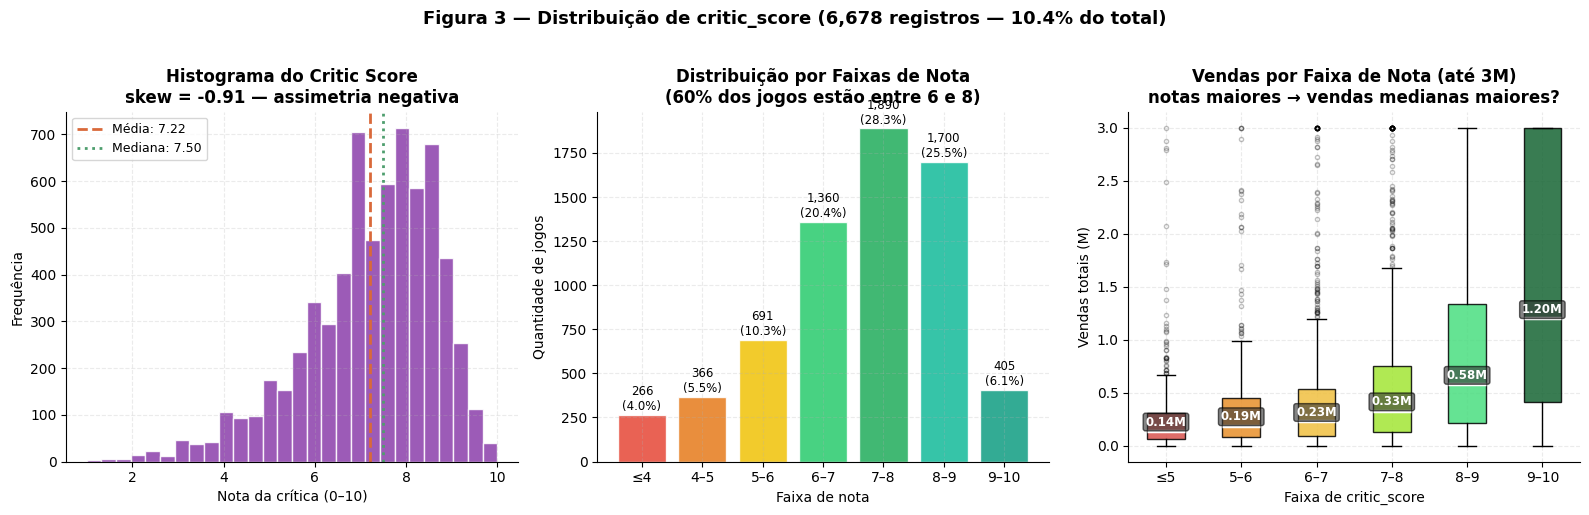

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Figura 3 — Distribuição de critic_score ({len(cs):,} registros — {len(cs)/len(df):.1%} do total)',
             fontsize=13, fontweight='bold', y=1.02)

# ── 5a: Histograma ───────────────────────────────────────────────────
ax = axes[0]
ax.hist(cs, bins=28, color=PURPLE, edgecolor='white', alpha=0.88)
ax.axvline(cs.mean(),   color=ORANGE, lw=2, ls='--', label=f'Média: {cs.mean():.2f}')
ax.axvline(cs.median(), color=GREEN,  lw=2, ls=':',  label=f'Mediana: {cs.median():.2f}')
ax.set_title(f'Histograma do Critic Score\nskew = {cs.skew():.2f} — assimetria negativa')
ax.set_xlabel('Nota da crítica (0–10)')
ax.set_ylabel('Frequência')
ax.legend(fontsize=9)

# ── 5b: Faixas de nota ───────────────────────────────────────────────
ax = axes[1]
bins_cs  = [0, 4, 5, 6, 7, 8, 9, 10]
labels_cs = ['≤4','4–5','5–6','6–7','7–8','8–9','9–10']
counts_cs = []
counts_cs.append((cs <= 4).sum())
for i in range(1, len(bins_cs) - 1):
    counts_cs.append(((cs > bins_cs[i]) & (cs <= bins_cs[i+1])).sum())
palette_cs = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60','#1abc9c','#16a085']

bars4 = ax.bar(labels_cs, counts_cs, color=palette_cs, edgecolor='white', alpha=0.88)
ax.set_title('Distribuição por Faixas de Nota\n(60% dos jogos estão entre 6 e 8)')
ax.set_xlabel('Faixa de nota')
ax.set_ylabel('Quantidade de jogos')
for bar, val in zip(bars4, counts_cs):
    pct = val / len(cs) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8.5)

# ── 5c: Boxplot de vendas por faixa de nota ──────────────────────────
ax = axes[2]
both = df.dropna(subset=['total_sales', 'critic_score']).copy()
both['faixa_nota'] = pd.cut(both['critic_score'],
    bins=[0, 5, 6, 7, 8, 9, 10],
    labels=['≤5', '5–6', '6–7', '7–8', '8–9', '9–10'])
grupos = [both[both['faixa_nota'] == f]['total_sales'].clip(upper=3).values
          for f in ['≤5','5–6','6–7','7–8','8–9','9–10']]
palette_bp = ['#d9534f','#e8902a','#f0c040','#a3e635','#4ade80','#166534']
bp = ax.boxplot(grupos, labels=['≤5','5–6','6–7','7–8','8–9','9–10'],
                patch_artist=True,
                medianprops=dict(color='white', linewidth=2.5),
                flierprops=dict(marker='o', ms=3, alpha=0.25, color=GRAY))
for patch, color in zip(bp['boxes'], palette_bp):
    patch.set_facecolor(color); patch.set_alpha(0.85)
ax.set_title('Vendas por Faixa de Nota (até 3M)\nnotas maiores → vendas medianas maiores?')
ax.set_xlabel('Faixa de critic_score')
ax.set_ylabel('Vendas totais (M)')
medians = [np.median(g) for g in grupos]
for i, med in enumerate(medians):
    ax.text(i + 1, med + 0.05, f'{med:.2f}M', ha='center', fontsize=8.5,
            fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#333', alpha=0.6))

plt.tight_layout()
plt.savefig('fig3_critic_score.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Distribuição das Variáveis Categóricas

### 6.1 Gênero e Console


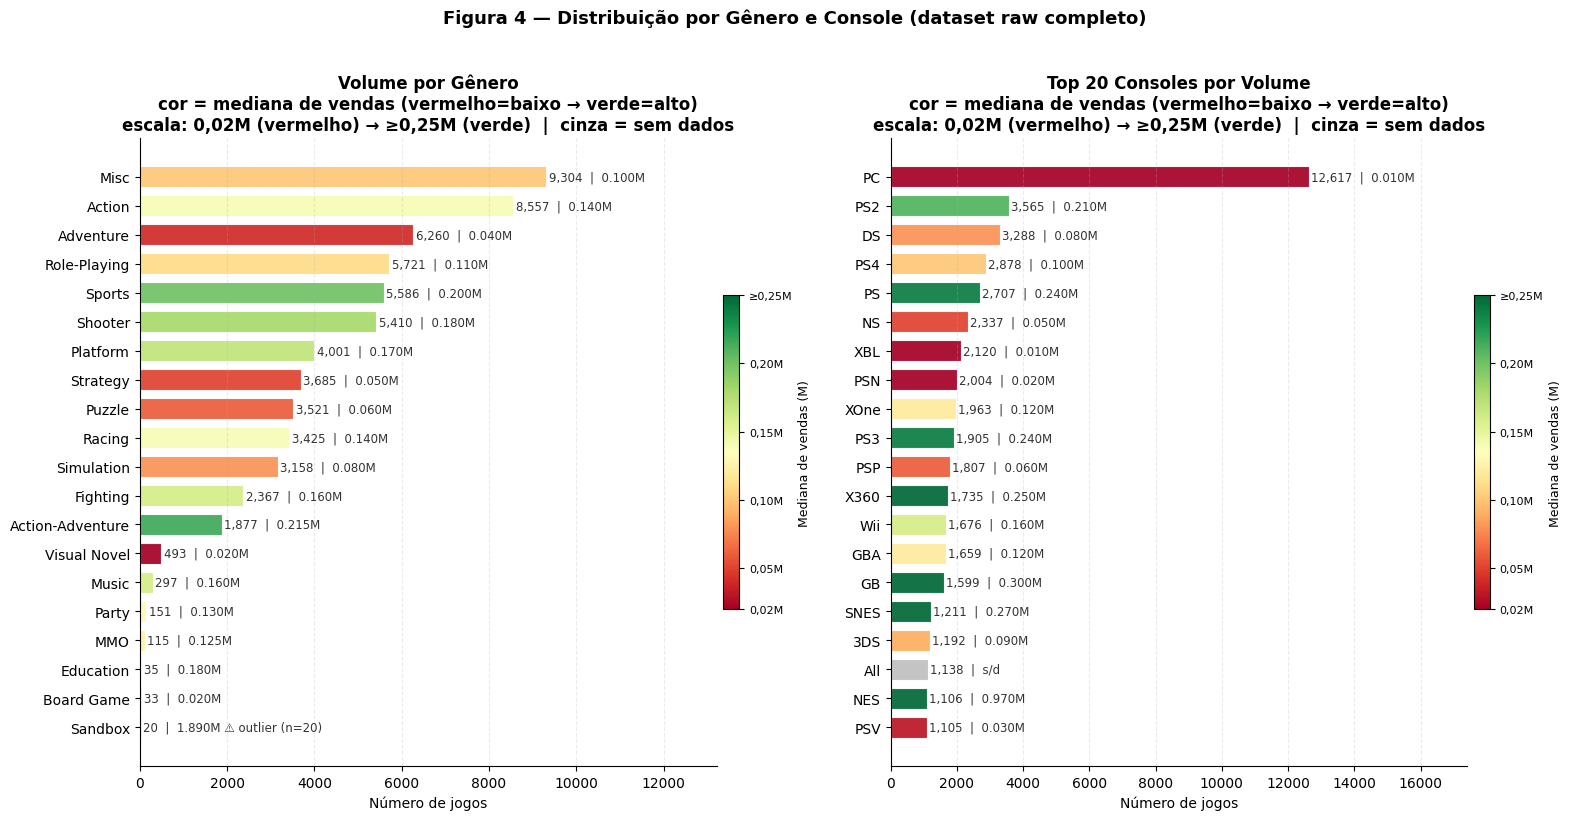

In [ ]:
genre_stats = df.groupby('genre').agg(
    jogos     = ('title', 'count'),
    med_sales = ('total_sales', 'median'),
    n_sales   = ('total_sales', 'count'),
).sort_values('jogos', ascending=True)

console_stats = df.groupby('console').agg(
    jogos     = ('title', 'count'),
    med_sales = ('total_sales', 'median'),
    n_sales   = ('total_sales', 'count'),
).sort_values('jogos', ascending=False).head(20).sort_values('jogos', ascending=True)

cmap  = cm.RdYlGn
norm_g = plt.Normalize(vmin=0.02, vmax=0.25)
norm_c = plt.Normalize(vmin=0.02, vmax=0.25)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Figura 4 — Distribuição por Gênero e Console (dataset raw completo)',
             fontsize=13, fontweight='bold', y=1.02)

# ── 6a: Gênero ───────────────────────────────────────────────────────
ax = axes[0]
colors_g = [cmap(norm_g(min(v, 0.25))) if not np.isnan(v) else (0.75, 0.75, 0.75, 1)
            for v in genre_stats['med_sales']]
ax.barh(genre_stats.index, genre_stats['jogos'],
        color=colors_g, edgecolor='white', linewidth=0.8, alpha=0.92, height=0.72)
for i, (idx, row) in enumerate(genre_stats.iterrows()):
    v = row['med_sales']
    suffix = '⚠ outlier (n=20)' if idx == 'Sandbox' else ''
    label_med = f'{v:.3f}M {suffix}' if not np.isnan(v) else 's/d'
    ax.text(row['jogos'] + 60, i, f"{int(row['jogos']):,}  |  {label_med}",
            va='center', fontsize=8.5, color='#333')
ax.set_xlabel('Número de jogos')
ax.set_title('Volume por Gênero\ncor = mediana de vendas (vermelho=baixo → verde=alto)\n'
             'escala: 0,02M (vermelho) → ≥0,25M (verde)  |  cinza = sem dados')
ax.set_xlim(0, genre_stats['jogos'].max() * 1.42)
ax.grid(axis='x', alpha=0.25); ax.grid(axis='y', visible=False)

# Colorbar gênero
sm_g = plt.cm.ScalarMappable(cmap=cmap, norm=norm_g)
sm_g.set_array([])
cbar_g = fig.colorbar(sm_g, ax=ax, shrink=0.5, pad=0.01, aspect=20)
cbar_g.set_label('Mediana de vendas (M)', fontsize=9)
cbar_g.set_ticks([0.02, 0.05, 0.10, 0.15, 0.20, 0.25])
cbar_g.set_ticklabels(['0,02M','0,05M','0,10M','0,15M','0,20M','≥0,25M'], fontsize=8)

# ── 6b: Console ──────────────────────────────────────────────────────
ax = axes[1]
colors_c = [cmap(norm_c(min(v, 0.25))) if not np.isnan(v) else (0.75, 0.75, 0.75, 1)
            for v in console_stats['med_sales']]
ax.barh(console_stats.index, console_stats['jogos'],
        color=colors_c, edgecolor='white', linewidth=0.8, alpha=0.92, height=0.72)
for i, (idx, row) in enumerate(console_stats.iterrows()):
    v = row['med_sales']
    label_med = f'{v:.3f}M' if not np.isnan(v) else 's/d'
    ax.text(row['jogos'] + 60, i, f"{int(row['jogos']):,}  |  {label_med}",
            va='center', fontsize=8.5, color='#333')
ax.set_xlabel('Número de jogos')
ax.set_title('Top 20 Consoles por Volume\ncor = mediana de vendas (vermelho=baixo → verde=alto)\n'
             'escala: 0,02M (vermelho) → ≥0,25M (verde)  |  cinza = sem dados')
ax.set_xlim(0, console_stats['jogos'].max() * 1.38)
ax.grid(axis='x', alpha=0.25); ax.grid(axis='y', visible=False)

sm_c = plt.cm.ScalarMappable(cmap=cmap, norm=norm_c)
sm_c.set_array([])
cbar_c = fig.colorbar(sm_c, ax=ax, shrink=0.5, pad=0.01, aspect=20)
cbar_c.set_label('Mediana de vendas (M)', fontsize=9)
cbar_c.set_ticks([0.02, 0.05, 0.10, 0.15, 0.20, 0.25])
cbar_c.set_ticklabels(['0,02M','0,05M','0,10M','0,15M','0,20M','≥0,25M'], fontsize=8)

plt.tight_layout()
plt.savefig('fig4_genero_console.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2 Publishers

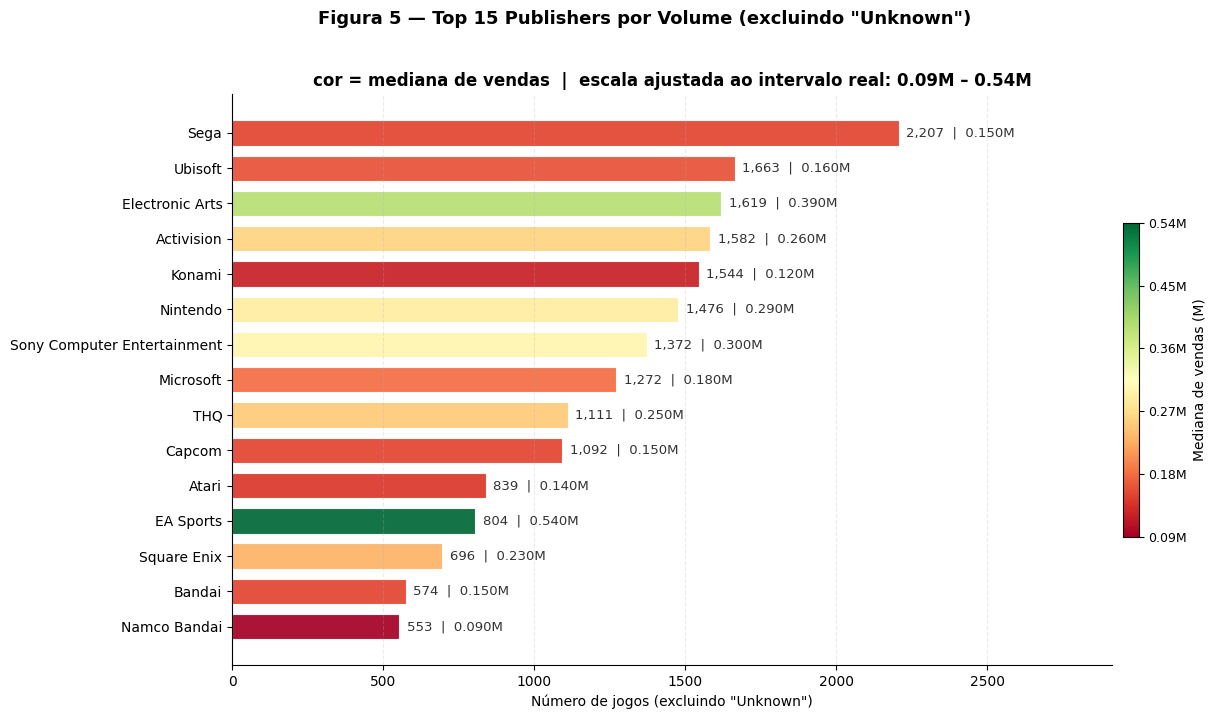


Publishers únicos (total): 3383
Registros 'Unknown':        8,842


In [ ]:
pub_stats = (df[df['publisher'] != 'Unknown']
             .groupby('publisher')
             .agg(jogos=('title','count'), med_sales=('total_sales','median'))
             .sort_values('jogos', ascending=False)
             .head(15)
             .sort_values('jogos', ascending=True))

v_min = pub_stats['med_sales'].min()
v_max = pub_stats['med_sales'].max()
norm_p = plt.Normalize(vmin=v_min, vmax=v_max)

fig, ax = plt.subplots(figsize=(13, 7))
fig.suptitle('Figura 5 — Top 15 Publishers por Volume (excluindo "Unknown")',
             fontsize=13, fontweight='bold', y=1.02)

colors_p = [cmap(norm_p(v)) if not np.isnan(v) else (0.75, 0.75, 0.75, 1)
            for v in pub_stats['med_sales']]
ax.barh(pub_stats.index, pub_stats['jogos'],
        color=colors_p, edgecolor='white', linewidth=0.8, alpha=0.92, height=0.72)

for i, (idx, row) in enumerate(pub_stats.iterrows()):
    v = row['med_sales']
    label = f"{int(row['jogos']):,}  |  {v:.3f}M" if not np.isnan(v) else f"{int(row['jogos']):,}  |  s/d"
    ax.text(row['jogos'] + 25, i, label, va='center', fontsize=9.5, color='#333')

ax.set_xlabel('Número de jogos (excluindo "Unknown")')
ax.set_title(f'cor = mediana de vendas  |  escala ajustada ao intervalo real: '
             f'{v_min:.2f}M – {v_max:.2f}M')
ax.set_xlim(0, pub_stats['jogos'].max() * 1.32)
ax.grid(axis='x', alpha=0.25); ax.grid(axis='y', visible=False)

sm_p = plt.cm.ScalarMappable(cmap=cmap, norm=norm_p)
sm_p.set_array([])
cbar_p = fig.colorbar(sm_p, ax=ax, shrink=0.55, pad=0.01, aspect=20)
cbar_p.set_label('Mediana de vendas (M)', fontsize=10)
ticks_p = np.linspace(v_min, v_max, 6)
cbar_p.set_ticks(ticks_p)
cbar_p.set_ticklabels([f'{t:.2f}M' for t in ticks_p], fontsize=9)

plt.tight_layout()
plt.savefig('fig5_publishers.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPublishers únicos (total): {df['publisher'].nunique()}")
print(f"Registros 'Unknown':        {(df['publisher']=='Unknown').sum():,}")


## 7. Evolução Temporal

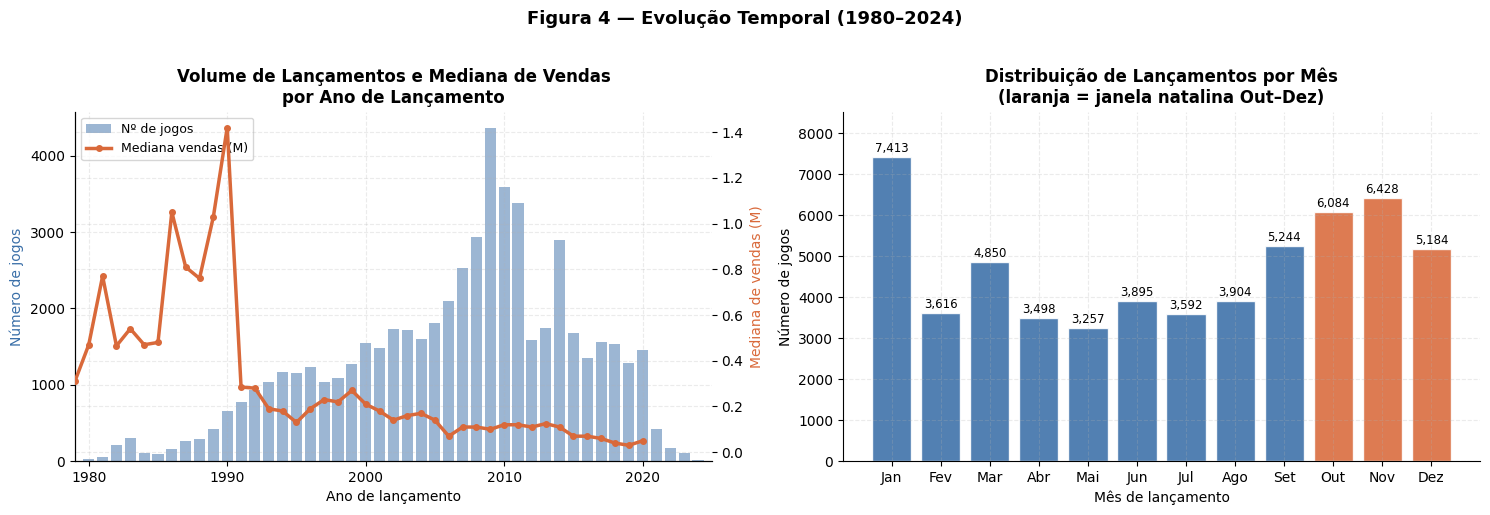

In [ ]:
year_counts = df['release_year'].value_counts().sort_index()
year_counts = year_counts[(year_counts.index >= 1980) & (year_counts.index <= 2024)]
year_sales  = df.groupby('release_year')['total_sales'].median()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Figura 4 — Evolução Temporal (1980–2024)',
             fontsize=13, fontweight='bold', y=1.02)

# ── 7a: Volume + mediana por ano ─────────────────────────────────────
ax  = axes[0]
ax2 = ax.twinx()
ax.bar(year_counts.index, year_counts.values,
       color=BLUE, alpha=0.5, width=0.8, label='Nº de jogos')
ax2.plot(year_sales.index, year_sales.values,
         color=ORANGE, lw=2.5, marker='o', ms=4, label='Mediana vendas (M)', zorder=5)
ax.set_xlabel('Ano de lançamento')
ax.set_ylabel('Número de jogos', color=BLUE)
ax2.set_ylabel('Mediana de vendas (M)', color=ORANGE)
ax.set_title('Volume de Lançamentos e Mediana de Vendas\npor Ano de Lançamento')
ax.set_xlim(1979, 2025)
l1, lb1 = ax.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2, lb1 + lb2, fontsize=9, loc='upper left')

# ── 7b: Lançamentos por mês ──────────────────────────────────────────
ax = axes[1]
month_counts = df['release_month'].value_counts().sort_index()
month_labels = ['Jan','Fev','Mar','Abr','Mai','Jun',
                'Jul','Ago','Set','Out','Nov','Dez']
month_colors = [ORANGE if m in [10, 11, 12] else BLUE for m in range(1, 13)]
bars = ax.bar(month_labels, [month_counts.get(m, 0) for m in range(1, 13)],
              color=month_colors, alpha=0.88, edgecolor='white')
ax.set_title('Distribuição de Lançamentos por Mês\n(laranja = janela natalina Out–Dez)')
ax.set_ylabel('Número de jogos')
ax.set_xlabel('Mês de lançamento')
for bar in bars:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8.5)
ax.set_ylim(0, max(month_counts.values) * 1.15)

plt.tight_layout()
plt.savefig('fig6_temporal.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Vendas Regionais

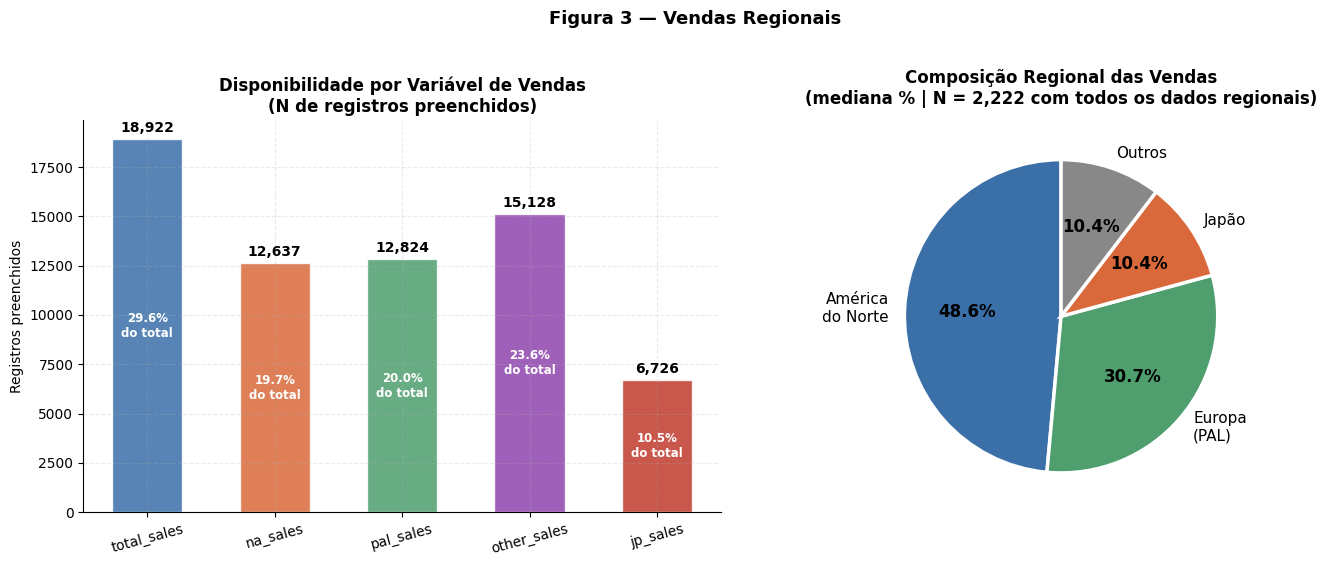

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Figura 3 — Vendas Regionais',
             fontsize=13, fontweight='bold', y=1.02)

# ── 8a: Disponibilidade por variável regional ────────────────────────
ax = axes[0]
reg_data = {
    'total_sales'  : df['total_sales'].notna().sum(),
    'na_sales'     : df['na_sales'].notna().sum(),
    'pal_sales'    : df['pal_sales'].notna().sum(),
    'other_sales'  : df['other_sales'].notna().sum(),
    'jp_sales'     : df['jp_sales'].notna().sum(),
}
bar_colors_r = [BLUE, ORANGE, GREEN, PURPLE, RED]
bars_r = ax.bar(list(reg_data.keys()), list(reg_data.values()),
                color=bar_colors_r, alpha=0.85, edgecolor='white', width=0.55)
ax.set_title('Disponibilidade por Variável de Vendas\n(N de registros preenchidos)')
ax.set_ylabel('Registros preenchidos')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars_r, reg_data.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
            f'{val/len(df):.1%}\ndo total', ha='center', va='center',
            fontsize=8.5, color='white', fontweight='bold')

# ── 8b: Composição regional das vendas ──────────────────────────────
ax = axes[1]
df_reg = df.dropna(subset=['total_sales','na_sales','jp_sales','pal_sales','other_sales'])
df_reg = df_reg[df_reg['total_sales'] > 0]
reg_pcts = {
    'América\ndo Norte' : (df_reg['na_sales'] / df_reg['total_sales']).median() * 100,
    'Europa\n(PAL)'     : (df_reg['pal_sales'] / df_reg['total_sales']).median() * 100,
    'Japão'              : (df_reg['jp_sales'] / df_reg['total_sales']).median() * 100,
    'Outros'             : (df_reg['other_sales'] / df_reg['total_sales']).median() * 100,
}
wedges, texts, autotexts = ax.pie(
    reg_pcts.values(), labels=reg_pcts.keys(),
    colors=[BLUE, GREEN, ORANGE, GRAY],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2.5),
    textprops=dict(fontsize=11)
)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold')
ax.set_title(f'Composição Regional das Vendas\n'
             f'(mediana % | N = {len(df_reg):,} com todos os dados regionais)', pad=12)

plt.tight_layout()
plt.savefig('fig7_regional.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Correlações

Duas correlações relevantes observadas nos dados:

**9.1** `critic_score` × `total_sales` — correlação moderada positiva  
**9.2** Vendas regionais × `total_sales` — correlação alta (esperada — são componentes do total)


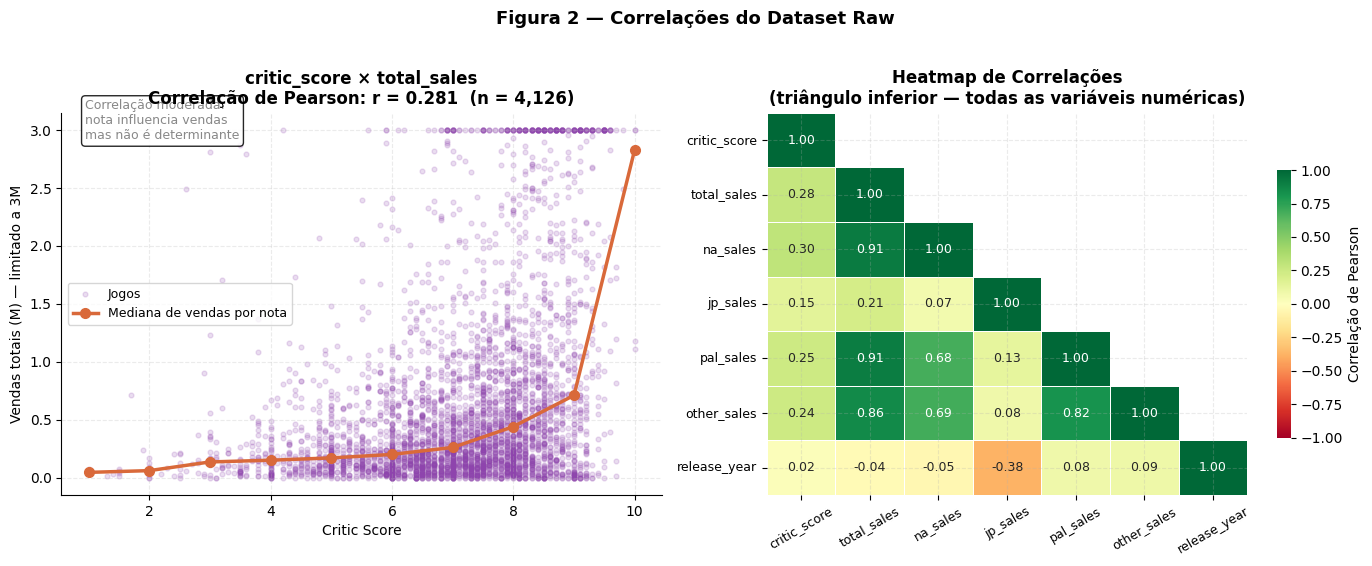

=== Correlações com total_sales ===
total_sales     1.000
na_sales        0.914
pal_sales       0.907
other_sales     0.859
critic_score    0.281
jp_sales        0.212
release_year   -0.039
Name: total_sales, dtype: float64

⚠ Atenção: na_sales, pal_sales e other_sales correlacionam fortemente
  com total_sales pois são componentes da soma — não features independentes.


In [ ]:
both = df.dropna(subset=['total_sales', 'critic_score']).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Figura 2 — Correlações do Dataset Raw',
             fontsize=13, fontweight='bold', y=1.02)

# ── 9a: Scatter critic_score vs total_sales ──────────────────────────
ax = axes[0]
ax.scatter(both['critic_score'], both['total_sales'].clip(upper=3),
           alpha=0.18, s=12, color=PURPLE, rasterized=True, label='Jogos')
both_copy = both.copy()
both_copy['score_round'] = both_copy['critic_score'].round(0)
avg_by_score = both_copy.groupby('score_round')['total_sales'].median()
ax.plot(avg_by_score.index, avg_by_score.values,
        color=ORANGE, lw=2.5, marker='o', ms=7,
        label='Mediana de vendas por nota', zorder=5)
r = both['critic_score'].corr(both['total_sales'])
ax.set_title(f'critic_score × total_sales\n'
             f'Correlação de Pearson: r = {r:.3f}  (n = {len(both):,})')
ax.set_xlabel('Critic Score')
ax.set_ylabel('Vendas totais (M) — limitado a 3M')
ax.legend(fontsize=9)
ax.text(0.04, 0.93,
        'Correlação moderada:\nnota influencia vendas\nmas não é determinante',
        transform=ax.transAxes, fontsize=9, color=GRAY,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

# ── 9b: Heatmap de correlações numéricas ────────────────────────────
ax = axes[1]
num_cols = ['critic_score', 'total_sales', 'na_sales', 'jp_sales',
            'pal_sales', 'other_sales', 'release_year']
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, ax=ax, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.7, 'label': 'Correlação de Pearson'}
)
ax.set_title('Heatmap de Correlações\n(triângulo inferior — todas as variáveis numéricas)')
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig('fig8_correlacoes.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Correlações com total_sales ===")
print(df[num_cols].corr()['total_sales'].sort_values(ascending=False).round(3))
print("\n⚠ Atenção: na_sales, pal_sales e other_sales correlacionam fortemente")
print("  com total_sales pois são componentes da soma — não features independentes.")


Com certeza! Vamos analisar o que podemos inferir das correlações apresentadas na **Figura 2 — Correlações do Dataset Raw**:

1.  **`critic_score` vs `total_sales` (Gráfico 9a):**
    *   **Correlação Positiva Moderada (r = 0.281):** Isso significa que, em geral, jogos com notas mais altas da crítica tendem a ter vendas totais maiores. Há uma relação, mas não é uma dependência muito forte.
    *   **Influência, mas não Determinante:** O gráfico de dispersão (scatter plot) e a linha laranja da mediana mostram uma tendência de aumento nas vendas medianas à medida que o `critic_score` sobe. No entanto, a grande dispersão dos pontos indica que uma nota alta **ajuda**, mas **não garante** um sucesso de vendas estrondoso. Muitos jogos com boas notas podem ainda ter vendas modestas, e outros com notas mais baixas (embora menos comuns no topo) podem surpreender.
    *   **Inferência:** A nota da crítica é um fator preditivo útil para as vendas, mas não é o único e nem o mais forte. Outros fatores (gênero, console, marketing, etc.) também são muito importantes.

2.  **Vendas Regionais vs `total_sales` (Heatmap 9b):**
    *   **Altíssima Correlação (ex: `na_sales` com `total_sales` é 0.91, `pal_sales` 0.90):** O heatmap mostra correlações muito altas entre as vendas regionais (`na_sales`, `pal_sales`, `other_sales`, `jp_sales`) e as vendas totais (`total_sales`).
    *   **Componentes da Soma:** Como o próprio notebook aponta, essa alta correlação é **esperada** porque as vendas totais são a **soma** das vendas regionais (Vendas Totais = Vendas América do Norte + Vendas Europa + Vendas Japão + Outras Vendas). Ou seja, elas não são variáveis independentes que *predizem* o total, mas sim *compõem* o total.
    *   **Inferência:** Isso nos diz que uma grande parte das vendas totais de um jogo vem dessas regiões específicas. Para uma análise preditiva, não usaríamos `na_sales`, `pal_sales`, etc., como *features independentes* para prever `total_sales`, pois elas são redundantes. Em vez disso, poderíamos usá-las para entender a distribuição geográfica das vendas ou como alvos para prever o desempenho em regiões específicas.

## 10. Tabela Resumo das Classes

In [ ]:
print("=" * 65)
print("RESUMO GERAL DO DATASET RAW")
print("=" * 65)

print(f"\nTotal de registros: {len(df):,}")
print(f"Colunas originais:  {len(df.columns) - 2} (+ 2 derivadas de release_date)")

print("\n--- Completude das colunas-chave ---")
for col in ['total_sales','critic_score','na_sales','jp_sales','pal_sales',
            'other_sales','release_date','last_update']:
    n    = df[col].notna().sum()
    pct  = n / len(df) * 100
    print(f"  {col:<18}: {n:>6,} registros ({pct:5.1f}%)")

print("\n--- Cardinalidade das categóricas ---")
for col in ['genre','console','publisher','developer']:
    u = df[col].nunique()
    print(f"  {col:<12}: {u:>5,} classes únicas")

print("\n--- Faixas de vendas (sem threshold definido) ---")
bins_r  = [0, 0.1, 0.5, 1.0, 2.0, 5.0, np.inf]
labels_r = ['< 0,1M','0,1–0,5M','0,5–1M','1–2M','2–5M','> 5M']
ts_cut   = pd.cut(df['total_sales'].dropna(), bins=bins_r, labels=labels_r)
for faixa, n in ts_cut.value_counts().sort_index().items():
    pct = n / ts_cut.notna().sum() * 100
    bar = '█' * int(pct / 2)
    print(f"  {faixa:<12}: {n:>5,} ({pct:5.1f}%)  {bar}")

print("\n--- Correlações com total_sales ---")
num_c = ['critic_score','release_year','na_sales','jp_sales','pal_sales','other_sales']
for col in num_c:
    sub = df.dropna(subset=['total_sales', col])
    r   = sub['total_sales'].corr(sub[col])
    print(f"  {col:<18}: r = {r:+.3f}  (n = {len(sub):,})")


RESUMO GERAL DO DATASET RAW

Total de registros: 64,016
Colunas originais:  14 (+ 2 derivadas de release_date)

--- Completude das colunas-chave ---
  total_sales       : 18,922 registros ( 29.6%)
  critic_score      :  6,678 registros ( 10.4%)
  na_sales          : 12,637 registros ( 19.7%)
  jp_sales          :  6,726 registros ( 10.5%)
  pal_sales         : 12,824 registros ( 20.0%)
  other_sales       : 15,128 registros ( 23.6%)
  release_date      : 56,965 registros ( 89.0%)
  last_update       : 17,879 registros ( 27.9%)

--- Cardinalidade das categóricas ---
  genre       :    20 classes únicas
  console     :    81 classes únicas
  publisher   : 3,383 classes únicas
  developer   : 8,862 classes únicas

--- Faixas de vendas (sem threshold definido) ---
  < 0,1M      : 7,586 ( 43.2%)  █████████████████████
  0,1–0,5M    : 6,666 ( 37.9%)  ██████████████████
  0,5–1M      : 1,835 ( 10.4%)  █████
  1–2M        :   959 (  5.5%)  ██
  2–5M        :   433 (  2.5%)  █
  > 5M        :  

## 11. Observações Finais da EDA

Com base na exploração do dataset raw, os principais achados são:

**Esparsidade:** apenas 29,6% dos registros possuem `total_sales` e apenas 10,4% possuem `critic_score`. Qualquer decisão de modelagem precisará lidar com esse gargalo.

**Assimetria de vendas:** `total_sales` tem skew = +8,77 — 75,3% dos jogos vendem menos de 0,5M de cópias. Poucos blockbusters inflam a média consideravelmente.

**Critic score** tem correlação moderada com vendas (r = 0,281) — é preditivo, mas não determinante. O boxplot por faixa confirma a tendência positiva.

**Gênero e console** mostram variação real na mediana de vendas — são candidatos naturais a features. Publisher tem alta cardinalidade (3.383 classes) que exigirá tratamento especial.

**Viés temporal:** consoles e anos mais antigos têm menos registros, mas os existentes tendem a ter vendas maiores — efeito de sobrevivência.

**Vendas regionais:** `na_sales`, `pal_sales` e `other_sales` correlacionam fortemente com `total_sales` (r > 0,88) por serem componentes da soma — não são features independentes.

> **Próxima etapa:** com base nessa EDA, definir critérios para seleção do subset de trabalho, threshold de classes e estratégia de pré-processamento.


## 12. Verificação de Duplicados

Vamos verificar se há linhas duplicadas no dataset.

In [ ]:
num_duplicates = df.duplicated().sum()

if num_duplicates > 0:
    print(f"Foram encontrados {num_duplicates} registros duplicados no dataset.")
    # Display some of the duplicate rows if desired
    # display(df[df.duplicated(keep=False)].sort_values(by=['title', 'console']).head())
else:
    print("Nenhum registro duplicado foi encontrado no dataset.")

Nenhum registro duplicado foi encontrado no dataset.
